In [1]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from scipy.stats import ttest_1samp
from scipy.stats import ttest_ind
import numpy as np
from statsmodels.stats.multitest import multipletests

In [2]:
SAM_number = 10.5
FDA_number = 3.108

In [3]:
colors_temp = {
    62: "#DF9966",
    57: "#FFC49B",
    52: "#FFEFD3",
    47: "#ADB6C4",
    42: "#3B6F8D",
    37: "#001B2E",
}

In [4]:
tempcurve = pd.read_csv("data/FlA_TempCurve.csv", sep=";")
tempcurve = tempcurve.drop(tempcurve.index[tempcurve["Plate"]!="ZP_TempCurve"])
tempcurve = tempcurve.drop(tempcurve.index[tempcurve["Protein"]=="Ctrl"])
tempcurve = tempcurve.drop(tempcurve.index[tempcurve["Protein"]=="Quad"])

tempcurve['FDA_conc'] = FDA_number*(tempcurve['FDA Area'])
tempcurve['SAM_conc'] = SAM_number*(tempcurve['SAM DG Area'])
tempcurve["%SAM converted"] = tempcurve['FDA_conc'] / (tempcurve['FDA_conc'] + tempcurve['SAM_conc']) * 100



temp_reference = tempcurve[tempcurve["Protein"] == "WT"]
# Merge the reference values back into the original DataFrame based on the same condition
tempcurve = tempcurve.merge(
    temp_reference[["Plate", "Timepoint", "SAM Conc.", "Temp.", "Replicate", "%SAM converted"]],
    on=["Plate", "Timepoint", "SAM Conc.", "Temp.", "Replicate"],
    suffixes=("", "_ref"),
    how="left"
)

# # Calculate Relative_Activity
# tempcurve["Relative_Activity"] = tempcurve["%SAM converted"] / tempcurve["%SAM converted_ref"]

# # Drop the intermediate reference column 
# tempcurve.drop(columns=["%SAM converted_ref"], inplace=True)

for temp in pd.unique(tempcurve["Temp."]):
    temp_subset = tempcurve[tempcurve["Temp."] == temp]
    ref = temp_subset[temp_subset["Protein"] == "WT"]
    wt_conv = ref["%SAM converted"].values
    wt_mean = np.mean(wt_conv)
    tempcurve.loc[tempcurve["Temp."] == temp, 'Relative_Activity'] = tempcurve.loc[tempcurve["Temp."] == temp, '%SAM converted'] / wt_mean
# ref = tempcurve[tempcurve["Protein"] == "WT"]
# wt_conv = ref["%SAM_converted"].values
# wt_mean = np.mean(wt_conv)

# tempcurve['Relative_Activity'] = tempcurve['%SAM_converted'] / wt_mean


In [5]:
tempcurve_conv = pd.melt(tempcurve, id_vars=["Protein", "Temp."], value_vars=["%SAM converted"])


tempcurve_rel = tempcurve.drop(tempcurve.index[tempcurve["Protein"] == "WT"].tolist())
tempcurve_rel = pd.melt(tempcurve_rel, id_vars=["Protein", "Temp."], value_vars=["Relative_Activity"])

# for mut in ["WT","H32L","H191E","G37D","S166A"]:
#     prev_conv = best_mutant_conv[mut]
#     i = tempcurve_conv.shape[0]
#     for val in prev_conv:
#         tempcurve_conv.loc[i] = [mut, 37, '%SAM converted', val]
#         i += 1
#     if mut != "WT":
#         prev_rel = best_mutant_rel[mut]
#         i = tempcurve_rel.shape[0]
#         for val in prev_rel:
#             tempcurve_rel.loc[i] = [mut, 37, 'Relative_Activity', val]
#             i += 1
tempcurve_conv = tempcurve_conv.groupby(by=["Protein", "Temp."])["value"].agg(["mean", "std"]).reset_index()
tempcurve_rel = tempcurve_rel.groupby(by=["Protein", "Temp."])["value"].agg(["mean", "std"]).reset_index()

In [6]:
tempcurve

,Sample ID,Plate,Protein,Timepoint,SAM Conc.,Temp.,Replicate,Inj. Volume,Dilution,FDA Area,SAM DG Area,FDA Corr.,SAM Corr.,%SAM converted,FDA_conc,SAM_conc,%SAM converted_ref,Relative_Activity
0,WT_37C_1,ZP_TempCurve,WT,2,300,37,1.0,40,2,0.7067,47.7515,0.35335,23.87575,0.436156,2.196424,501.39075,0.436156,0.966928
1,H191E_37C_1,ZP_TempCurve,H191E,2,300,37,1.0,40,2,0.7848,43.4624,0.39240,21.73120,0.531645,2.439158,456.35520,0.436156,1.178623
2,H32L_37C_1,ZP_TempCurve,H32L,2,300,37,1.0,40,2,0.5536,39.6191,0.27680,19.80955,0.411899,1.720589,416.00055,0.436156,0.913153
3,G37D_37C_1,ZP_TempCurve,G37D,2,300,37,1.0,40,2,0.5823,37.3898,0.29115,18.69490,0.458868,1.809788,392.59290,0.436156,1.017281
4,S166A_37C_1,ZP_TempCurve,S166A,2,300,37,1.0,40,2,0.6306,37.6361,0.31530,18.81805,0.493506,1.959905,395.17905,0.436156,1.094071
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,H191E_62C_2,ZP_TempCurve,H191E,2,300,62,2.0,40,2,0.1470,38.1542,0.07350,19.07710,0.113913,0.456876,400.61910,0.065826,1.807596
68,H32L_62C_2,ZP_TempCurve,H32L,2,300,62,2.0,40,2,0.0834,38.6799,0.04170,19.33995,0.063782,0.259207,406.13895,0.065826,1.012104
69,G37D_62C_2,ZP_TempCurve,G37D,2,300,62,2.0,40,2,0.0793,34.6094,0.03965,17.30470,0.067776,0.246464,363.39870,0.065826,1.075489
70,S166A_62C_2,ZP_TempCurve,S166A,2,300,62,2.0,40,2,0.1219,39.2175,0.06095,19.60875,0.091921,0.378865,411.78375,0.065826,1.458632


In [7]:
# Order categories
#protein_order = ["WT", "S166A", "H191E", "H32L", "G37D", "Quad", "K237R"]
protein_order = ["WT", "S166A", "H191E", "H32L", "G37D", "K237R"]
temp_order = [37, 42, 47, 52, 57, 62]


tempcurve_conv["Protein"] = pd.Categorical(
    tempcurve_conv["Protein"], categories=protein_order, ordered=True
)
tempcurve_conv["Temp."] = pd.Categorical(
    tempcurve_conv["Temp."], categories=temp_order, ordered=True
)
tempcurve_conv = tempcurve_conv.sort_values(["Protein", "Temp."])


tempcurve_rel['Protein'] = pd.Categorical(
    tempcurve_rel['Protein'], categories=protein_order, ordered=True
)
tempcurve_rel['Temp.'] = pd.Categorical(
    tempcurve_rel['Temp.'], categories=temp_order, ordered=True
)
tempcurve_rel = tempcurve_rel.sort_values(["Protein", "Temp."])

In [8]:
# Get csv file 
relact_raw = pd.read_csv("data/FlA_ZP_RelAct_full.csv", sep=";")
relact_raw['FDA_conc'] = FDA_number*(relact_raw['FDA_Area'])
relact_raw['SAM_conc'] = SAM_number*(relact_raw['SAM_Area'])
relact_raw["%SAM_converted"] = relact_raw['FDA_conc'] / (relact_raw['FDA_conc'] + relact_raw['SAM_conc']) * 100

relact = relact_raw.drop(relact_raw.index[relact_raw["Protein"] == "Ctrl"])

SAM = 300
t = 2
subset_2 = relact.loc[(relact["Time(min)"] == t) & (relact["SAM_conc(uM)"] == SAM)]

ref_2 = subset_2[subset_2["Protein"] == "WT"]
wt_conv_2 = ref_2['%SAM_converted'].values
wt_mean_2 = np.mean(wt_conv_2)

subset_2['Relative_Activity'] = subset_2['%SAM_converted'] / wt_mean_2

original_ = subset_2.copy()
original_ = original_[original_['Protein'].isin(protein_order)]
original_['Temp.'] = 37

original_conv = pd.melt(original_, id_vars=["Protein", "Temp."], value_vars=["%SAM_converted"])
original_rel = original_.drop(original_.index[original_["Protein"] == "WT"].tolist())
original_rel = pd.melt(original_rel, id_vars=["Protein", "Temp."], value_vars=["Relative_Activity"])

original_conv = original_conv.groupby(by=["Protein", "Temp."])["value"].agg(["mean", "std"]).reset_index()
original_rel = original_rel.groupby(by=["Protein", "Temp."])["value"].agg(["mean", "std"]).reset_index()

C:\Users\dhard\AppData\Local\Temp\ipykernel_35856\543452437.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_2['Relative_Activity'] = subset_2['%SAM_converted'] / wt_mean_2


In [9]:
# Get csv file 
relact_raw = pd.read_csv("data/FlA_ZP_RatEng.csv", sep=";")
relact_raw['FDA_conc'] = FDA_number*(relact_raw['FDA Area'])
relact_raw['SAM_conc'] = SAM_number*(relact_raw['SAM DG Area'])
relact_raw["%SAM_converted"] = relact_raw['FDA_conc'] / (relact_raw['FDA_conc'] + relact_raw['SAM_conc']) * 100

relact = relact_raw.drop(relact_raw.index[relact_raw["Protein"] == "Ctrl"])

SAM = 300
t = 2
subset_2 = relact.loc[(relact["Time(min)"] == t) & (relact["SAM_conc(uM)"] == SAM)]

ref_2 = subset_2[subset_2["Protein"] == "WT"]
wt_conv_2 = ref_2['%SAM_converted'].values
wt_mean_2 = np.mean(wt_conv_2)

subset_2['Relative_Activity'] = subset_2['%SAM_converted'] / wt_mean_2

original_ = subset_2.copy()
original_ = original_[original_['Protein'].isin(protein_order)]
original_['Temp.'] = 37

rateng_conv = original_.drop(original_.index[original_["Protein"] == "WT"].tolist())
rateng_conv = pd.melt(rateng_conv, id_vars=["Protein", "Temp."], value_vars=["%SAM_converted"])
rateng_rel = original_.drop(original_.index[original_["Protein"] == "WT"].tolist())
rateng_rel = pd.melt(rateng_rel, id_vars=["Protein", "Temp."], value_vars=["Relative_Activity"])

rateng_conv = rateng_conv.groupby(by=["Protein", "Temp."])["value"].agg(["mean", "std"]).reset_index()
rateng_rel = rateng_rel.groupby(by=["Protein", "Temp."])["value"].agg(["mean", "std"]).reset_index()

C:\Users\dhard\AppData\Local\Temp\ipykernel_35856\1592564631.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_2['Relative_Activity'] = subset_2['%SAM_converted'] / wt_mean_2


In [10]:
rateng_conv

,Protein,Temp.,mean,std
0,K237R,37,0.463945,0.011731


In [11]:
original_conv['Protein']

0     G37D
1    H191E
2     H32L
3    S166A
4       WT
Name: Protein, dtype: object

In [12]:
# Change the values of the variants at 37C to those from the original experiment
plot_conv = tempcurve_conv.copy()
for mut in protein_order:
    if mut != "K237R":
        prev_conv = original_conv[original_conv['Protein'] == mut]
        plot_conv.loc[(plot_conv['Protein'] == mut) & (plot_conv['Temp.'] == 37), 'mean'] = prev_conv['mean'].values[0]
        plot_conv.loc[(plot_conv['Protein'] == mut) & (plot_conv['Temp.'] == 37), 'std'] = prev_conv['std'].values[0]
    else:
        prev_conv = rateng_conv[rateng_conv['Protein'] == mut]
        plot_conv.loc[(plot_conv['Protein'] == mut) & (plot_conv['Temp.'] == 37), 'mean'] = prev_conv['mean'].values[0]
        plot_conv.loc[(plot_conv['Protein'] == mut) & (plot_conv['Temp.'] == 37), 'std'] = prev_conv['std'].values[0]

plot_conv['Time'] = 2


plot_rel = tempcurve_rel.copy()
for mut in protein_order[1:]:
    if mut != "K237R":
        prev_rel = original_rel[original_rel['Protein'] == mut]
        plot_rel.loc[(plot_rel['Protein'] == mut) & (plot_rel['Temp.'] == 37), 'mean'] = prev_rel['mean'].values[0]
        plot_rel.loc[(plot_rel['Protein'] == mut) & (plot_rel['Temp.'] == 37), 'std'] = prev_rel['std'].values[0]
    else:
        prev_rel = rateng_rel[rateng_rel['Protein'] == mut]
        plot_rel.loc[(plot_rel['Protein'] == mut) & (plot_rel['Temp.'] == 37), 'mean'] = prev_rel['mean'].values[0]
        plot_rel.loc[(plot_rel['Protein'] == mut) & (plot_rel['Temp.'] == 37), 'std'] = prev_rel['std'].values[0]

plot_rel['Time'] = 2

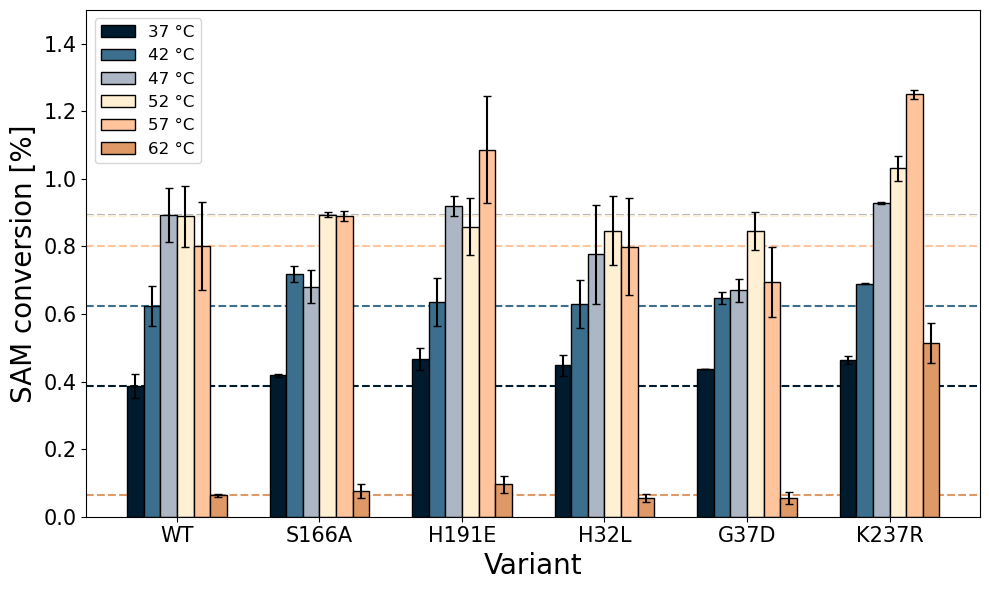

In [13]:
# Grouped bar plot
proteins = plot_conv["Protein"].unique()
temps = plot_conv["Temp."].unique()
x = np.arange(len(proteins))  # X locations for variants
width = 0.7  # Bar width (adjust if more temps)

fig, ax = plt.subplots(figsize=(10, 6))

for i, t in enumerate(temps):
    subset = plot_conv[plot_conv["Temp."] == t]
    ax.bar(
        x + i * width/len(temps),
        subset["mean"],
        yerr=subset["std"],
        width=width/len(temps),
        label=f"{t} °C",
        edgecolor="black",
        linewidth=1.0,
        capsize=3,
        color=colors_temp[t],
        zorder=2
    )
# Labels and title
ax.set_xlabel("Variant",fontsize=20)
ax.set_ylabel("SAM conversion [%]",fontsize=20)
ax.set_xticks(x + width/2 - width/(2*len(temps)))
ax.set_xticklabels(proteins, rotation=0, ha="center")
ax.legend(fontsize=12)

ax.tick_params(axis='both', which='major', labelsize=15)

# Add horizontal line at WT values
for i,row in plot_conv[plot_conv["Protein"] == "WT"].iterrows():
    wt_value = row['mean']
    t = row['Temp.']
    ax.axhline(y=wt_value, linestyle="--",color=colors_temp[t],zorder=1)

ax.set_ylim(0, 1.5)

plt.tight_layout()
plt.show()

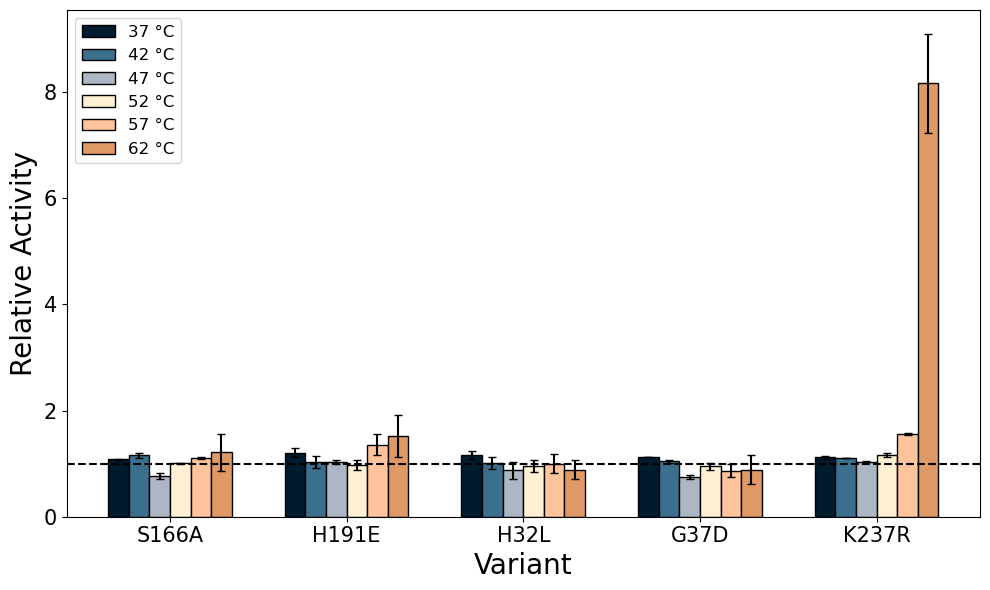

In [14]:
# Grouped bar plot
proteins = plot_rel["Protein"].unique()
temps = plot_rel["Temp."].unique()
x = np.arange(len(proteins))  # X locations for variants
width = 0.7  # Bar width (adjust if more temps)

fig, ax = plt.subplots(figsize=(10, 6))

for i, t in enumerate(temps):
    subset = plot_rel[plot_rel["Temp."] == t]
    ax.bar(
        x + i * width/len(temps),
        subset["mean"],
        yerr=subset["std"],
        width=width/len(temps),
        label=f"{t} °C",
        edgecolor="black",
        linewidth=1.0,
        capsize=3,
        color=colors_temp[t],
    )

# Add horizontal line at y=1
ax.axhline(y=1, color="black", linestyle="--")

# Labels
ax.set_xlabel("Variant",fontsize=20)
ax.set_ylabel("Relative Activity",fontsize=20)
ax.set_xticks(x + width/2 - width/(2*len(temps)))
ax.set_xticklabels(proteins, rotation=0, ha="center")
ax.legend(fontsize=12)

ax.tick_params(axis='both', which='major', labelsize=15)

plt.tight_layout()
plt.show()

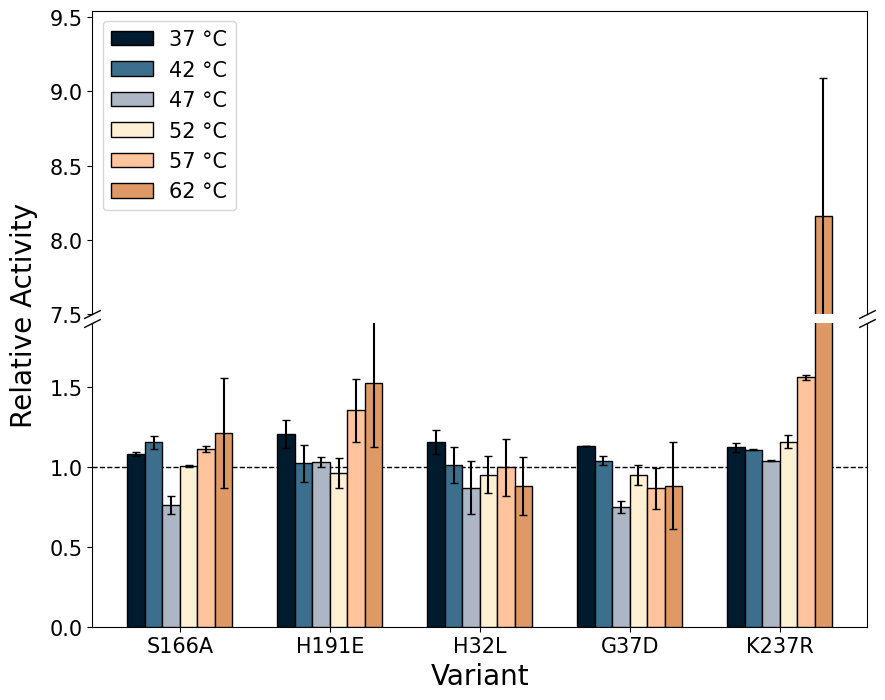

In [15]:
proteins = plot_rel["Protein"].unique()
temps     = plot_rel["Temp."].unique()
x = np.arange(len(proteins))
width = 0.70

# pick the cut ranges
bottom_ylim = (0.0, 1.9)  # most bars
y_max = float((plot_rel["mean"] + plot_rel["std"]).max())
top_ylim    = (7.5, max(8.6, y_max * 1.05))  # outlier region

# helper to draw grouped bars on a given axis
def draw_grouped(ax):
    for i, t in enumerate(temps):
        sub = plot_rel[plot_rel["Temp."] == t]
        ax.bar(
            x + i * width/len(temps),
            sub["mean"],
            yerr=sub["std"],
            width=width/len(temps),
            label=f"{t} °C",
            edgecolor="black",
            linewidth=1.0,
            capsize=3,
            color=colors_temp[t],
            zorder=3
        )

# ---- template-style broken axis ----
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 8))
fig.subplots_adjust(hspace=0.03)  # space between axes

# plot same bars on both axes
draw_grouped(ax1)
draw_grouped(ax2)

# zoom / limits (top = outliers, bottom = bulk)
ax1.set_ylim(*top_ylim)
ax2.set_ylim(*bottom_ylim)

# reference line on bottom panel
ax2.axhline(1.0, color="black", linestyle="--", linewidth=1, zorder=2)

# hide the spines between the two axes, set ticks like in the template
ax1.spines.bottom.set_visible(False)
ax2.spines.top.set_visible(False)
ax1.xaxis.tick_top()
ax1.tick_params(top=False, labeltop=False)
ax2.xaxis.tick_bottom()

# slanted break markers (exact template approach)
d = .5  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
ax1.plot([0, 1], [0, 0], transform=ax1.transAxes, **kwargs)
ax2.plot([0, 1], [1, 1], transform=ax2.transAxes, **kwargs)

# labels / ticks / legend
ax2.set_xlabel("Variant", fontsize=20)
ax2.set_xticks(x + width/2 - width/(2*len(temps)))
ax2.set_xticklabels(proteins, rotation=0, ha="center")

ax1.set_yticks(np.arange(top_ylim[0], top_ylim[1], 0.5))

ax1.set_ylabel("Relative Activity", fontsize=20)
ax1.yaxis.set_label_coords(-0.07, 0)

ax1.tick_params(axis="y", labelsize=15)
ax2.tick_params(axis="both", which="major", labelsize=15)

# legend once (top-left above bottom axis)
ax1.legend(fontsize=15)


#plt.tight_layout()
plt.show()


# More timepoints

In [16]:
temp_opt_pd = pd.read_excel("data/FlA_ZS_top_temp_optimum_calcs.xlsx",sheet_name='corrected data')
temp_opt_pd["%SAM_converted"] = temp_opt_pd['FDA conc'] / (temp_opt_pd['FDA conc'] + temp_opt_pd['SAM conc']) * 100
temp_opt_pd['Protein'] = temp_opt_pd['Condition'].str.split('_').str[0]
temp_opt_pd['Time'] = temp_opt_pd['Condition'].str.split('_').str[2].str[:2].astype(int)
temp_opt_pd['Temp.'] = temp_opt_pd['Condition'].str.split('_').str[1].astype(int)
temp_opt_pd

,Condition,FDA area,SAM deg area,FDA conc,SAM conc,%SAM_converted,Protein,Time,Temp.
0,WT_37_10-1,0.6451,12.2121,2.004971,128.22705,1.539538,WT,10,37
1,WT_37_30-1,1.3735,7.8699,4.268838,82.63395,4.912199,WT,30,37
2,WT_37_60-1,2.0079,7.0077,6.240553,73.58085,7.818145,WT,60,37
3,WT_42_10-1,0.8210,7.7752,2.551668,81.63960,3.030799,WT,10,42
4,WT_42_30-1,1.6598,6.9989,5.158658,73.48845,6.559247,WT,30,42
...,...,...,...,...,...,...,...,...,...
319,K237R_47_30-3,8.0913,34.2400,25.147760,359.52000,6.537527,K237R,30,47
320,K237R_47_60-3,11.1518,30.6648,34.659794,321.98040,9.718421,K237R,60,47
321,K237R_52_10-3,4.9330,36.6571,15.331764,384.89955,3.830726,K237R,10,52
322,K237R_52_30-3,8.5793,33.3757,26.664464,350.44485,7.070752,K237R,30,52


In [17]:
# Extract WT data and average over temps
for temp in pd.unique(temp_opt_pd["Temp."]):
    for time in pd.unique(temp_opt_pd["Time"]):
        temp_subset = temp_opt_pd[(temp_opt_pd["Temp."] == temp) & (temp_opt_pd["Time"] == time)]
        ref = temp_subset[temp_subset["Protein"] == "WT"]
        wt_conv = ref["%SAM_converted"].values
        wt_mean = np.mean(wt_conv)
        temp_opt_pd.loc[(temp_opt_pd["Temp."] == temp) & (temp_opt_pd["Time"] == time), 'Relative_Activity'] = temp_opt_pd.loc[(temp_opt_pd["Temp."] == temp) & (temp_opt_pd["Time"] == time), '%SAM_converted'] / wt_mean

In [18]:
temp_opt_pd.Protein.replace({'S116A':'S166A'}, inplace=True)
temp_opt_pd.Protein.value_counts()

C:\Users\dhard\AppData\Local\Temp\ipykernel_35856\3870823270.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  temp_opt_pd.Protein.replace({'S116A':'S166A'}, inplace=True)


Protein
WT       54
S166A    54
H32L     54
G37D     54
H191E    54
K237R    54
Name: count, dtype: int64

In [19]:
temp_opt_conv = pd.melt(temp_opt_pd, id_vars=["Protein", "Temp.",'Time'], value_vars=["%SAM_converted"])


temp_opt_rel = temp_opt_pd.drop(temp_opt_pd.index[temp_opt_pd["Protein"] == "WT"].tolist())
temp_opt_rel = pd.melt(temp_opt_rel, id_vars=["Protein", "Temp.",'Time'], value_vars=["Relative_Activity"])


temp_opt_conv = temp_opt_conv.groupby(by=["Protein", "Temp.",'Time'])["value"].agg(["mean", "std"]).reset_index()
temp_opt_rel = temp_opt_rel.groupby(by=["Protein", "Temp.",'Time'])["value"].agg(["mean", "std"]).reset_index()

temp_opt_conv = pd.concat([plot_conv,temp_opt_conv], ignore_index=True)
temp_opt_rel = pd.concat([plot_rel,temp_opt_rel], ignore_index=True)

In [20]:
temp_opt_rel.Protein.value_counts()

Protein
S166A    24
H191E    24
H32L     24
G37D     24
K237R    24
Name: count, dtype: int64

In [21]:
protein_order = ["WT", "S166A", "H191E", "H32L", "G37D", "K237R"]
temp_order = [37, 42, 47, 52, 57, 62]
time_order = [2,10,30,60]


temp_opt_conv["Protein"] = pd.Categorical(
    temp_opt_conv["Protein"], categories=protein_order, ordered=True
)
temp_opt_conv["Temp."] = pd.Categorical(
    temp_opt_conv["Temp."], categories=temp_order, ordered=True
)
temp_opt_conv["Time"] = pd.Categorical(
    temp_opt_conv["Time"], categories=time_order, ordered=True
)
temp_opt_conv = temp_opt_conv.sort_values(["Protein", "Temp.", "Time"])


temp_opt_rel['Protein'] = pd.Categorical(
    temp_opt_rel['Protein'], categories=protein_order, ordered=True
)
temp_opt_rel['Temp.'] = pd.Categorical(
    temp_opt_rel['Temp.'], categories=temp_order, ordered=True
)
temp_opt_rel['Time'] = pd.Categorical(
    temp_opt_rel['Time'], categories=time_order, ordered=True
)
temp_opt_rel = temp_opt_rel.sort_values(["Protein", "Temp.", "Time"])

In [22]:
temp_opt_rel

,Protein,Temp.,mean,std,Time
0,S166A,37,1.080411,0.013380,2
102,S166A,37,1.031954,0.051940,10
103,S166A,37,0.916189,0.012082,30
104,S166A,37,0.934922,0.033318,60
1,S166A,42,1.153581,0.038627,2
...,...,...,...,...,...
98,K237R,57,1.533781,0.102705,60
29,K237R,62,8.161958,0.926898,2
99,K237R,62,5.563949,1.598221,10
100,K237R,62,5.684411,0.851400,30


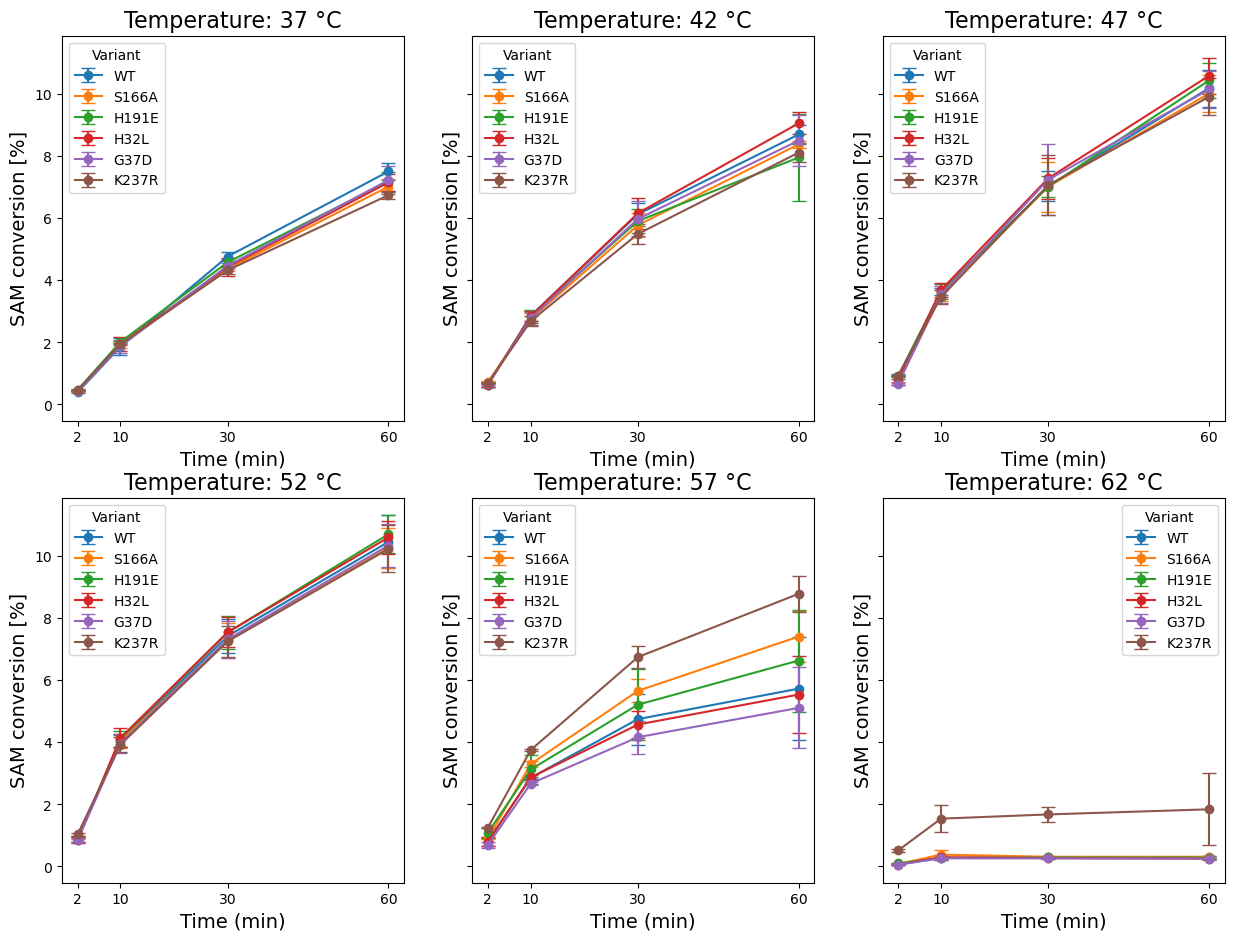

In [23]:
# Plotting convertion as a function of time for different temperatures (subplots = 3 x 2)

fig, axes = plt.subplots(2, 3, figsize=(15, 11), sharey=True)
axes = axes.flatten()

for i, (temp,ax) in enumerate(zip(temp_order,axes)):
    for prot in protein_order:
        subset = temp_opt_conv[(temp_opt_conv["Temp."] == temp) & (temp_opt_conv["Protein"] == prot)]

        # Plot while starting in 0,0



        ax.errorbar(
            subset["Time"],
            subset["mean"],
            yerr=subset["std"],
            label=prot,
            marker='o',
            linestyle='-',
            capsize=5
        )
    ax.set_title(f'Temperature: {temp} °C', fontsize=16)
    ax.set_xlabel('Time (min)', fontsize=14)
    ax.set_ylabel('SAM conversion [%]', fontsize=14)
    ax.legend(title='Variant', fontsize=10)
    #ax.grid(True)
    ax.set_xticks(time_order)


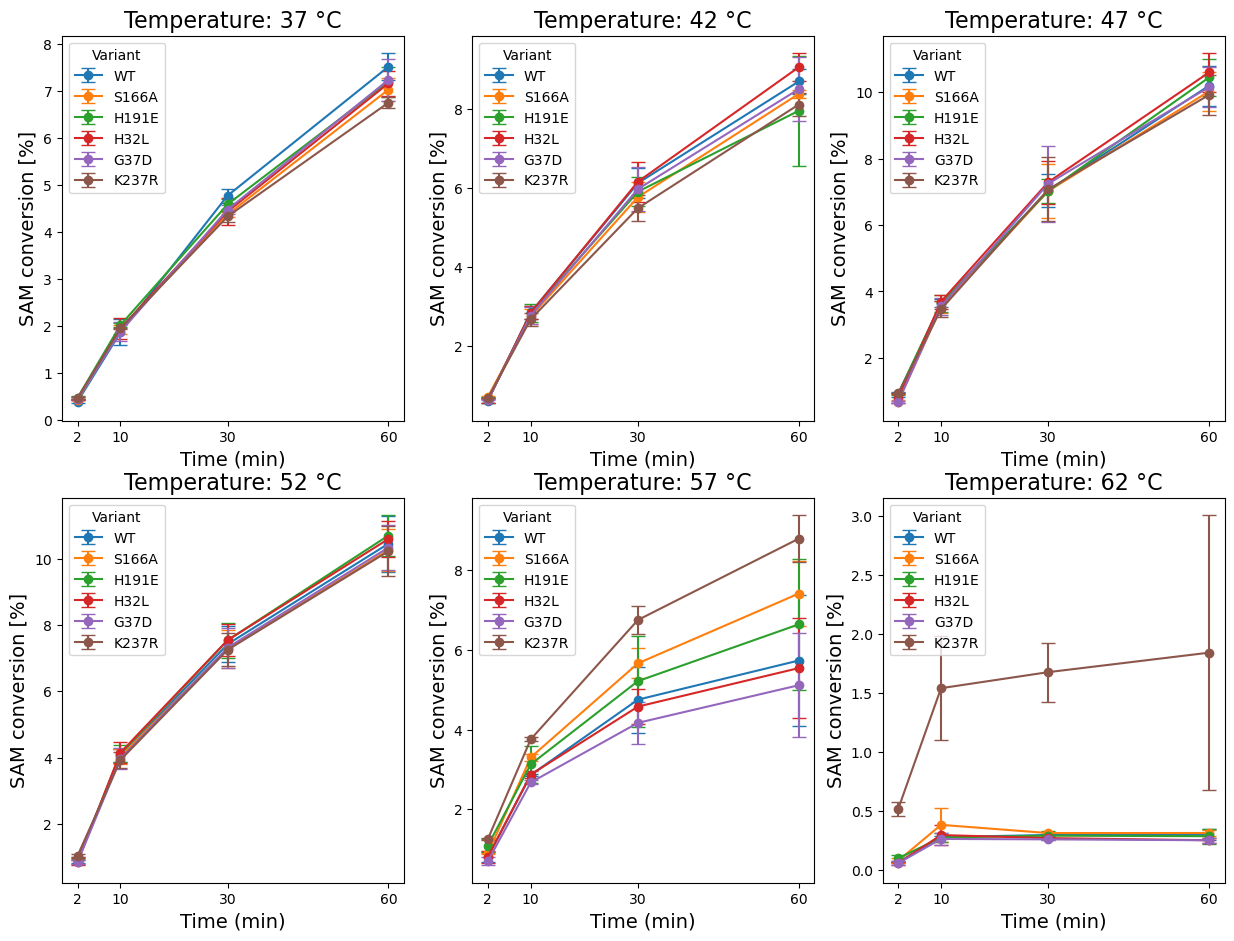

In [24]:
# Plotting convertion as a function of time for different temperatures (subplots = 3 x 2)

fig, axes = plt.subplots(2, 3, figsize=(15, 11))
axes = axes.flatten()

for i, (temp,ax) in enumerate(zip(temp_order,axes)):
    for prot in protein_order:
        subset = temp_opt_conv[(temp_opt_conv["Temp."] == temp) & (temp_opt_conv["Protein"] == prot)]

        # Plot while starting in 0,0



        ax.errorbar(
            subset["Time"],
            subset["mean"],
            yerr=subset["std"],
            label=prot,
            marker='o',
            linestyle='-',
            capsize=5
        )
    ax.set_title(f'Temperature: {temp} °C', fontsize=16)
    ax.set_xlabel('Time (min)', fontsize=14)
    ax.set_ylabel('SAM conversion [%]', fontsize=14)
    ax.legend(title='Variant', fontsize=10)
    #ax.grid(True)
    ax.set_xticks(time_order)

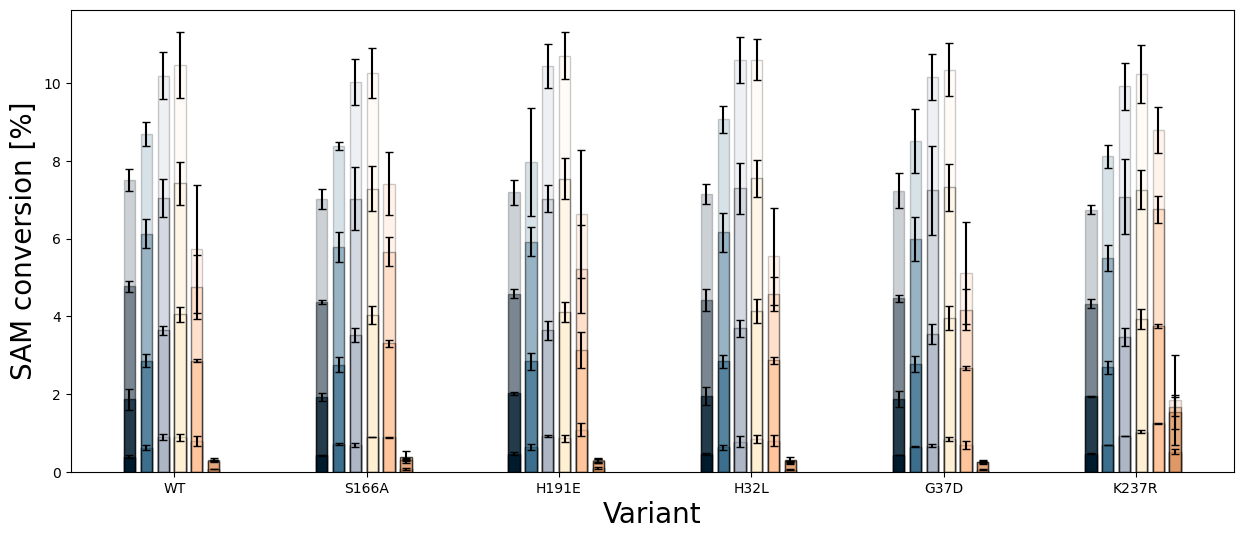

In [32]:
# Plot the conversions for temp = 47 and 52C as stacked bar plots for different timepoints
# The x-axis should be the variants, the y-axis the conversion percentage
# Each temperature should be a separate bar, with the bars from the same variant grouped together
# The colors should decrease in alpha for each timepoint (2,10,30,60)
fig, ax = plt.subplots(figsize=(15, 6))
temps_to_plot = [37,42,47, 52, 57, 62]
alphas = [1.0, 0.7, 0.4, 0.2]
width = 0.35  # Width of each bar
proteins = temp_opt_conv["Protein"].unique()
x = np.arange(len(proteins))  # X locations for variants
for i, temp in enumerate(temps_to_plot):
    subset = temp_opt_conv[temp_opt_conv["Temp."] == temp]
    for j, time in enumerate(time_order):
        time_subset = subset[subset["Time"] == time]
        ax.bar(
            x + i * width/4,
            time_subset["mean"],
            yerr=time_subset["std"],
            width=width / len(temps_to_plot),
            label=f"{temp} °C, {time} min",
            edgecolor="black",
            linewidth=1.0,
            capsize=3,
            ecolor="black",
            color=colors_temp[temp],
            alpha=alphas[j],
        )
# Labels and title
ax.set_xlabel("Variant", fontsize=20)
ax.set_ylabel("SAM conversion [%]", fontsize=20)
ax.set_xticks(x + width / 2 - width / (2 * len(temps_to_plot))+ width/4)
ax.set_xticklabels(proteins, rotation=0, ha="center")
#ax.set_ylim(0, 20)
#ax.legend(fontsize=12)
plt.show()

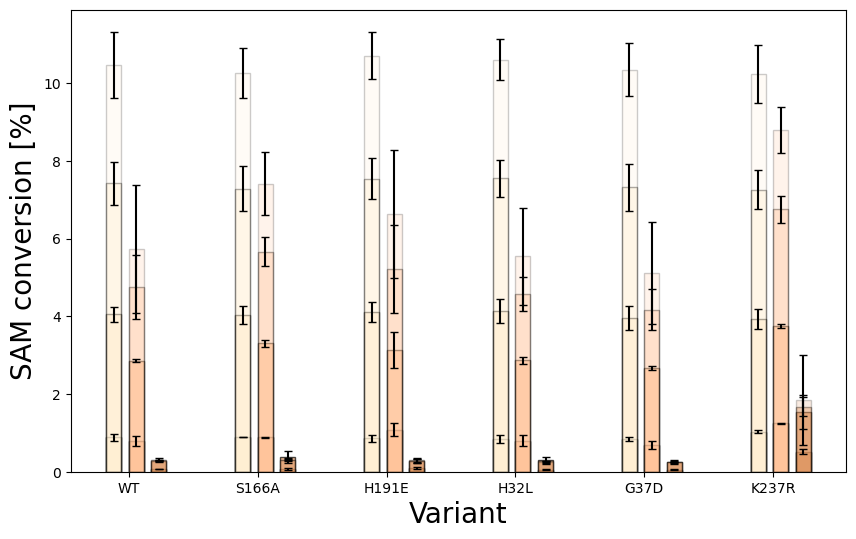

In [26]:
# Plot the conversions for temp = 47 and 52C as stacked bar plots for different timepoints
# The x-axis should be the variants, the y-axis the conversion percentage
# Each temperature should be a separate bar, with the bars from the same variant grouped together
# The colors should decrease in alpha for each timepoint (2,10,30,60)
fig, ax = plt.subplots(figsize=(10, 6))
temps_to_plot = [52, 57, 62]
alphas = [1.0, 0.7, 0.4, 0.2]
width = 0.35  # Width of each bar
proteins = temp_opt_conv["Protein"].unique()
x = np.arange(len(proteins))  # X locations for variants
for i, temp in enumerate(temps_to_plot):
    subset = temp_opt_conv[temp_opt_conv["Temp."] == temp]
    for j, time in enumerate(time_order):
        time_subset = subset[subset["Time"] == time]
        ax.bar(
            x + i * width/2,
            time_subset["mean"],
            yerr=time_subset["std"],
            width=width / len(temps_to_plot),
            label=f"{temp} °C, {time} min",
            edgecolor="black",
            linewidth=1.0,
            capsize=3,
            ecolor="black",
            color=colors_temp[temp],
            alpha=alphas[j],
        )
# Labels and title
ax.set_xlabel("Variant", fontsize=20)
ax.set_ylabel("SAM conversion [%]", fontsize=20)
ax.set_xticks(x + width / 2 - width / (2 * len(temps_to_plot)))#+ width/4)
ax.set_xticklabels(proteins, rotation=0, ha="center")
#ax.set_ylim(0, 20)
#ax.legend(fontsize=12)
plt.show()

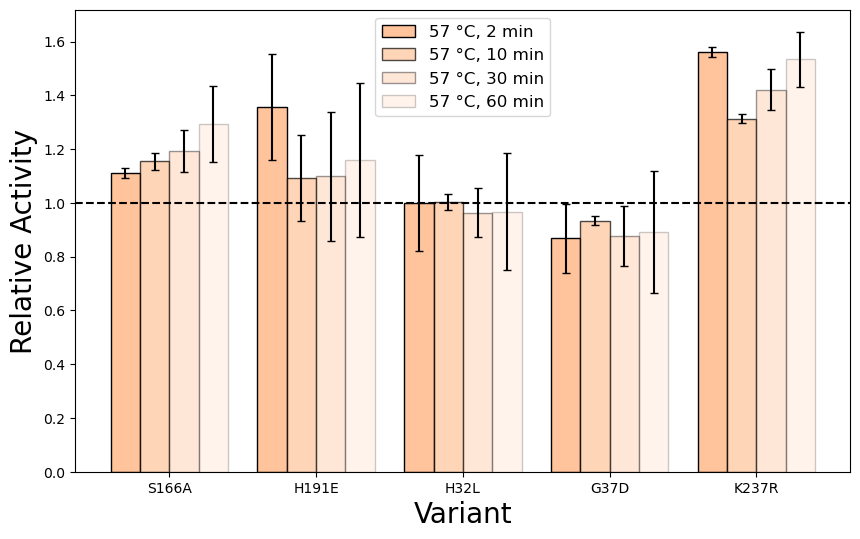

In [27]:
# Plot the relative activity for temp = 62C as grouped bar plot for different timepoints
# The x-axis should be the variants, the y-axis the relative activity
# Each timepoint should be a separate bar, with the bars from the same variant grouped together
# The colors should decrease in alpha for each timepoint (2,10,30,60)
fig, ax = plt.subplots(figsize=(10, 6))
temps_to_plot = [57]
alphas = [1.0, 0.7, 0.4, 0.2]
width = 0.2  # Width of each bar
proteins = temp_opt_rel["Protein"].unique()
x = np.arange(len(proteins))  # X locations for variants
for i, temp in enumerate(temps_to_plot):
    subset = temp_opt_rel[temp_opt_rel["Temp."] == temp]
    for j, time in enumerate(time_order):
        time_subset = subset[subset["Time"] == time]
        ax.bar(
            x + j * width,
            time_subset["mean"],
            yerr=time_subset["std"],
            width=width / len(temps_to_plot),
            label=f"{temp} °C, {time} min",
            edgecolor="black",
            linewidth=1.0,
            capsize=3,
            ecolor="black",
            color=colors_temp[temp],
            alpha=alphas[j],
        )
# Labels and title
ax.set_xlabel("Variant", fontsize=20)
ax.set_ylabel("Relative Activity", fontsize=20)
ax.set_xticks(x + width / 2 - width / (2 * len(temps_to_plot)) + width * 1.5)
ax.set_xticklabels(proteins, rotation=0, ha="center")
#ax.set_ylim(0, 2)

ax.axhline(y=1, color="black", linestyle="--")

ax.legend(fontsize=12)
plt.show()

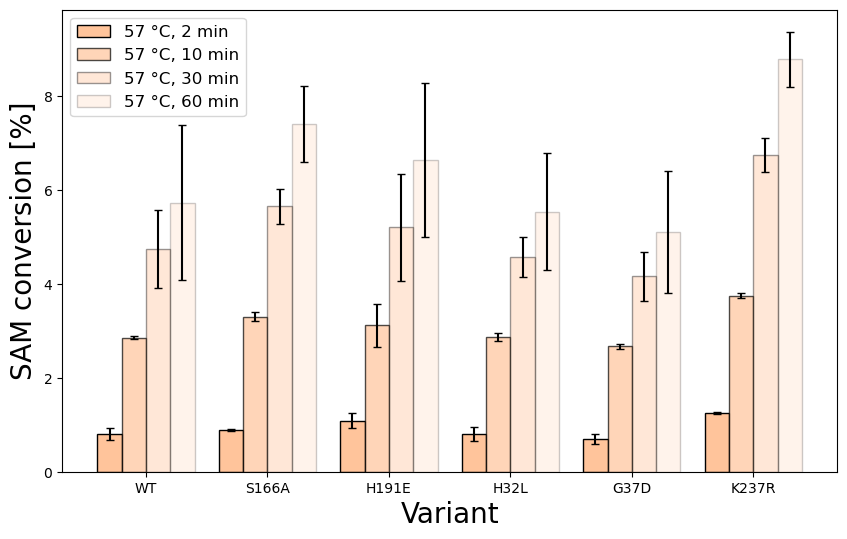

In [28]:
# Plot the relative activity for temp = 62C as grouped bar plot for different timepoints
# The x-axis should be the variants, the y-axis the relative activity
# Each timepoint should be a separate bar, with the bars from the same variant grouped together
# The colors should decrease in alpha for each timepoint (2,10,30,60)
fig, ax = plt.subplots(figsize=(10, 6))
temps_to_plot = [57]
alphas = [1.0, 0.7, 0.4, 0.2]
width = 0.2  # Width of each bar
proteins = temp_opt_conv["Protein"].unique()
x = np.arange(len(proteins))  # X locations for variants
for i, temp in enumerate(temps_to_plot):
    subset = temp_opt_conv[temp_opt_conv["Temp."] == temp]
    for j, time in enumerate(time_order):
        time_subset = subset[subset["Time"] == time]
        ax.bar(
            x + j * width,
            time_subset["mean"],
            yerr=time_subset["std"],
            width=width / len(temps_to_plot),
            label=f"{temp} °C, {time} min",
            edgecolor="black",
            linewidth=1.0,
            capsize=3,
            ecolor="black",
            color=colors_temp[temp],
            alpha=alphas[j],
        )
# Labels and title
ax.set_xlabel("Variant", fontsize=20)
ax.set_ylabel("SAM conversion [%]", fontsize=20)
ax.set_xticks(x + width / 2 - width / (2 * len(temps_to_plot)) + width * 1.5)
ax.set_xticklabels(proteins, rotation=0, ha="center")
#ax.set_ylim(0, 2)
ax.legend(fontsize=12)
plt.show()

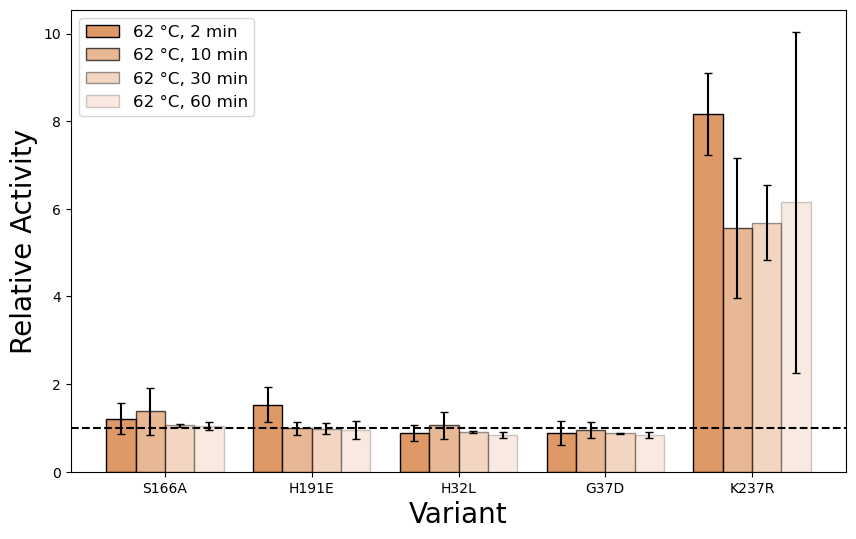

In [29]:
# Plot the relative activity for temp = 62C as grouped bar plot for different timepoints
# The x-axis should be the variants, the y-axis the relative activity
# Each timepoint should be a separate bar, with the bars from the same variant grouped together
# The colors should decrease in alpha for each timepoint (2,10,30,60)
fig, ax = plt.subplots(figsize=(10, 6))
temps_to_plot = [62]
alphas = [1.0, 0.7, 0.4, 0.2]
width = 0.2  # Width of each bar
proteins = temp_opt_rel["Protein"].unique()
x = np.arange(len(proteins))  # X locations for variants
for i, temp in enumerate(temps_to_plot):
    subset = temp_opt_rel[temp_opt_rel["Temp."] == temp]
    for j, time in enumerate(time_order):
        time_subset = subset[subset["Time"] == time]
        ax.bar(
            x + j * width,
            time_subset["mean"],
            yerr=time_subset["std"],
            width=width / len(temps_to_plot),
            label=f"{temp} °C, {time} min",
            edgecolor="black",
            linewidth=1.0,
            capsize=3,
            ecolor="black",
            color=colors_temp[temp],
            alpha=alphas[j],
        )
# Labels and title
ax.set_xlabel("Variant", fontsize=20)
ax.set_ylabel("Relative Activity", fontsize=20)
ax.set_xticks(x + width / 2 - width / (2 * len(temps_to_plot)) + width * 1.5)
ax.set_xticklabels(proteins, rotation=0, ha="center")
#ax.set_ylim(0, 2)

ax.axhline(y=1, color="black", linestyle="--")

ax.legend(fontsize=12)
plt.show()

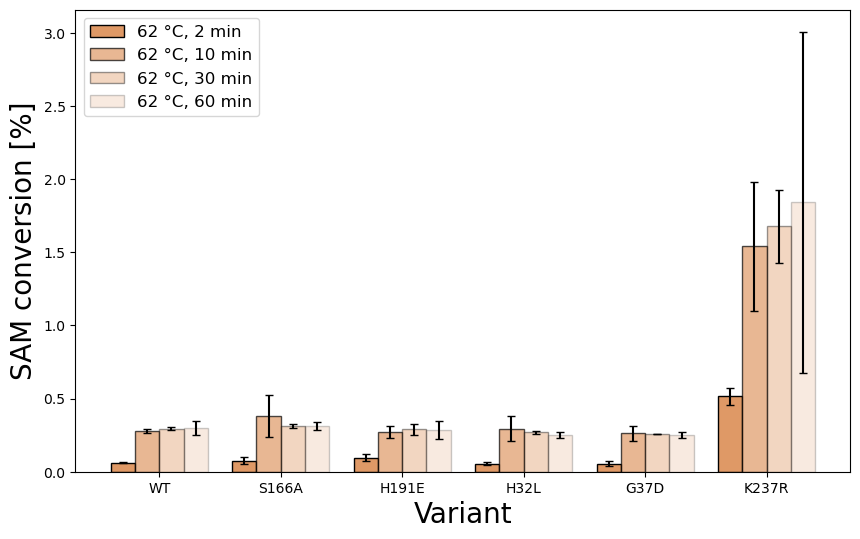

In [30]:
# Plot the relative activity for temp = 62C as grouped bar plot for different timepoints
# The x-axis should be the variants, the y-axis the relative activity
# Each timepoint should be a separate bar, with the bars from the same variant grouped together
# The colors should decrease in alpha for each timepoint (2,10,30,60)
fig, ax = plt.subplots(figsize=(10, 6))
temps_to_plot = [62]
alphas = [1.0, 0.7, 0.4, 0.2]
width = 0.2  # Width of each bar
proteins = temp_opt_conv["Protein"].unique()
x = np.arange(len(proteins))  # X locations for variants
for i, temp in enumerate(temps_to_plot):
    subset = temp_opt_conv[temp_opt_conv["Temp."] == temp]
    for j, time in enumerate(time_order):
        time_subset = subset[subset["Time"] == time]
        ax.bar(
            x + j * width,
            time_subset["mean"],
            yerr=time_subset["std"],
            width=width / len(temps_to_plot),
            label=f"{temp} °C, {time} min",
            edgecolor="black",
            linewidth=1.0,
            capsize=3,
            ecolor="black",
            color=colors_temp[temp],
            alpha=alphas[j],
        )
# Labels and title
ax.set_xlabel("Variant", fontsize=20)
ax.set_ylabel("SAM conversion [%]", fontsize=20)
ax.set_xticks(x + width / 2 - width / (2 * len(temps_to_plot)) + width * 1.5)
ax.set_xticklabels(proteins, rotation=0, ha="center")
#ax.set_ylim(0, 2)
ax.legend(fontsize=12)
plt.show()